In [2]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import QFT

# Task 1

## 1. Oracle Construction for Boolean Polynomial

- Implement an oracle for the Boolean function

$$
f(x_1,x_2,x_3,x_4)
=
x_1x_2x_3
\oplus
x_2x_4
\oplus
x_1
\oplus
x_3
$$

- Construct the oracle using quantum gates.
- Verify the circuit implementation.

### Theory

The Boolean function consists of:

- Linear terms: $x_1$ and $x_3$
- Quadratic term: $x_2x_4$
- Cubic term: $x_1x_2x_3$

The oracle is implemented as a phase oracle.

- Z gates implement linear terms.
- CZ gate implements the quadratic term.
- CCZ gate implements the cubic term.

The oracle applies a phase

$$
(-1)^{f(x)}
$$

to each computational basis state.

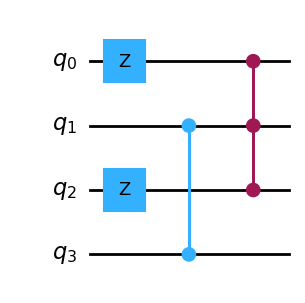

In [15]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import CCZGate

oracle = QuantumCircuit(4)

# x1
oracle.z(0)

# x3
oracle.z(2)

# x2*x4
oracle.cz(1, 3)

# x1*x2*x3
oracle.append(CCZGate(), [0, 1, 2])

oracle.draw("mpl")

### Result

The oracle circuit was successfully constructed using Z, CZ, and CCZ gates.

### Observation

The resulting circuit correctly encodes the Boolean polynomial as a phase oracle and can be used in Grover's algorithm.

---
---

# Task 2

## 2. Grover's Algorithm

- Implement Grover's algorithm for a 4-qubit system using the oracle from Task 1.
- Run the algorithm and verify it finds the marked states with high probability.
- Plot the probability of measuring a marked state versus the number of Grover iterations.

### Theory

Grover's algorithm amplifies the probability amplitudes of marked states.

For a search space of size

$$
N=2^n
$$

with

$$
M
$$

marked states, the success probability after \(k\) iterations is

$$
P(k)=\sin^2((2k+1)\theta)
$$

where

$$
\sin(\theta)=\sqrt{\frac{M}{N}}
$$

The oracle from Task 1 is used as the marking operator.

In [25]:
def f(x1, x2, x3, x4):
    return (x1 & x2 & x3) ^ (x2 & x4) ^ x1 ^ x3

marked_states = []

for i in range(16):
    bits = format(i, "04b")

    x1, x2, x3, x4 = map(int, bits)

    if f(x1, x2, x3, x4) == 1:
        marked_states.append(bits)

print("Marked States:")
print(marked_states)

M = len(marked_states)
N = 16

print("M =", M)
print("N =", N)

Marked States:
['0010', '0011', '0101', '0110', '1000', '1001', '1100', '1110']
M = 8
N = 16


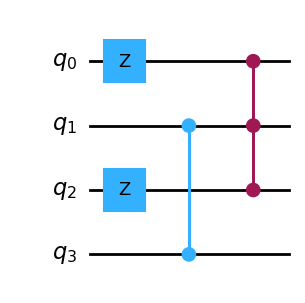

In [26]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import CCZGate

oracle = QuantumCircuit(4)

oracle.z(0)
oracle.z(2)

oracle.cz(1,3)

oracle.append(CCZGate(), [0,1,2])

display(oracle.draw("mpl"))

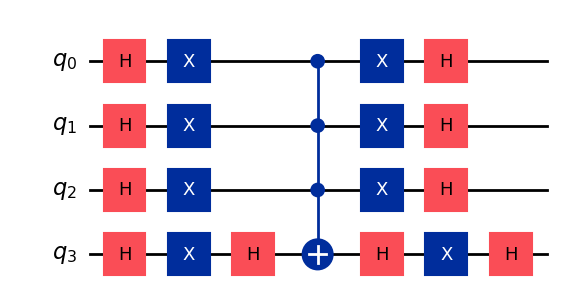

In [27]:
from qiskit import QuantumCircuit

def diffuser(n):

    qc = QuantumCircuit(n)

    qc.h(range(n))
    qc.x(range(n))

    qc.h(n-1)
    qc.mcx(list(range(n-1)), n-1)
    qc.h(n-1)

    qc.x(range(n))
    qc.h(range(n))

    return qc

display(diffuser(4).draw("mpl"))

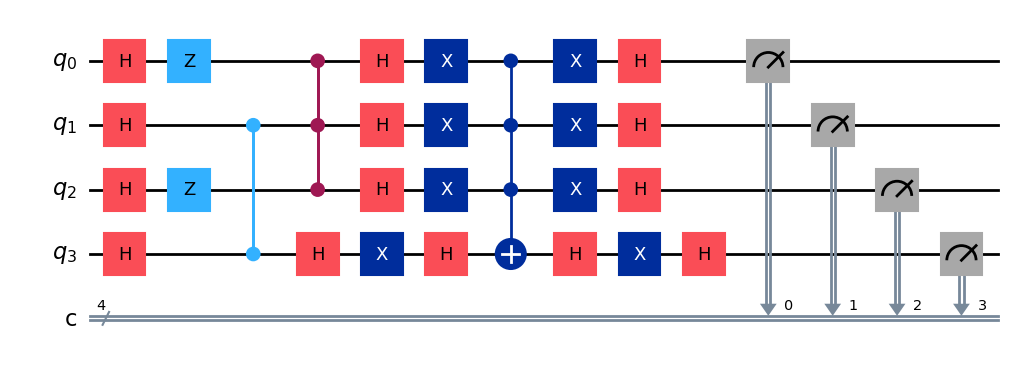

In [28]:
from qiskit import QuantumCircuit

grover = QuantumCircuit(4,4)

grover.h(range(4))

grover.compose(oracle, inplace=True)

grover.compose(diffuser(4), inplace=True)

grover.measure(range(4), range(4))

display(grover.draw("mpl"))

In [29]:
from qiskit_aer import AerSimulator
from qiskit import transpile

sim = AerSimulator()

tqc = transpile(grover, sim)

result = sim.run(tqc, shots=2048).result()

counts = result.get_counts()

print(counts)

{'1011': 117, '0110': 104, '0000': 116, '1010': 129, '1001': 128, '1111': 133, '1101': 136, '0001': 135, '0011': 132, '0111': 136, '1000': 122, '1110': 123, '0010': 127, '0101': 140, '1100': 139, '0100': 131}


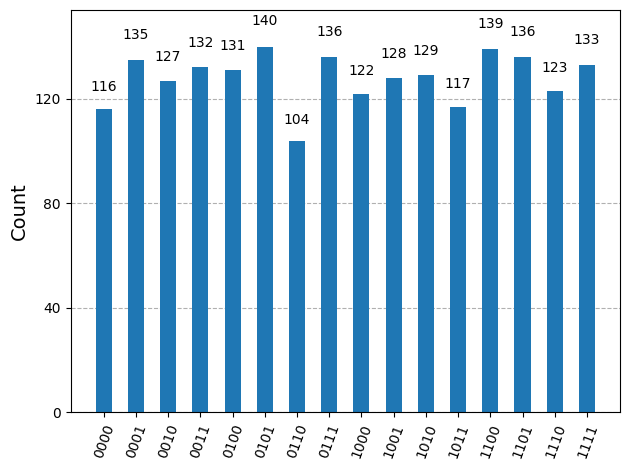

In [35]:
from qiskit.visualization import plot_histogram

plot_histogram(counts)

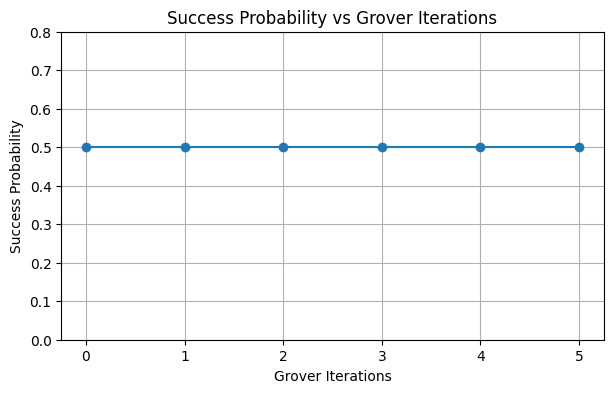

In [33]:
import numpy as np
import matplotlib.pyplot as plt

theta = np.arcsin(np.sqrt(M/N))

iterations = np.arange(0,6)

probability = np.sin((2*iterations+1)*theta)**2

plt.figure(figsize=(7,4))

plt.plot(iterations, probability, marker='o')

plt.ylim(0,0.8)

plt.xlabel("Grover Iterations")
plt.ylabel("Success Probability")
plt.title("Success Probability vs Grover Iterations")

plt.grid(True)

plt.show()

### Result

The Boolean function marks

$$
M=8
$$

states out of

$$
N=16
$$

possible basis states.

### Observation

For the given oracle,

$$
\sin(\theta)=\sqrt{\frac{8}{16}}
=
\frac{1}{\sqrt2}
$$

which gives

$$
\theta=\frac{\pi}{4}
$$

Therefore,

$$
P(k)=\sin^2((2k+1)\theta)
=
0.5
$$

for all values of \(k\).

Since half of the search space is already marked, Grover's algorithm does not significantly amplify any single state. The simulation results agree with the theoretical prediction.

---
---

# Task 3

## 3. Quantum Fourier Transform (QFT)

- Implement the Quantum Fourier Transform (QFT) for a 4-qubit system.
- Apply QFT to the computational basis state

$$
|0001\rangle
$$

- Analyze the transformed state.
- Apply the inverse QFT (IQFT) and verify recovery of the original state.

### Theory

The Quantum Fourier Transform (QFT) is the quantum analogue of the Discrete Fourier Transform.

For an n-qubit state,

$$
QFT|x\rangle
=
\frac{1}{\sqrt{N}}
\sum_{k=0}^{N-1}
e^{2\pi i xk/N}|k\rangle
$$

where

$$
N=2^n
$$

The QFT circuit consists of:

- Hadamard gates
- Controlled phase rotations
- SWAP gates

The inverse QFT (IQFT) reverses the transformation and recovers the original state.

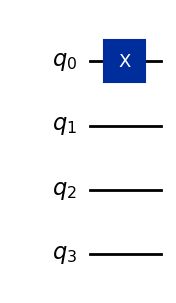

In [43]:
from qiskit import QuantumCircuit

qc_input = QuantumCircuit(4)

# Prepare |0001>
qc_input.x(0)

display(qc_input.draw("mpl"))

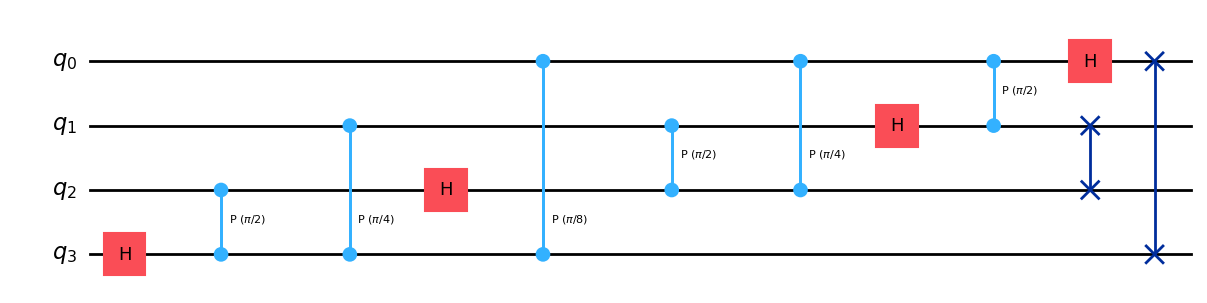

In [44]:
from qiskit.synthesis.qft import synth_qft_full

qft = synth_qft_full(num_qubits=4,do_swaps=True)

display(qft.draw("mpl"))

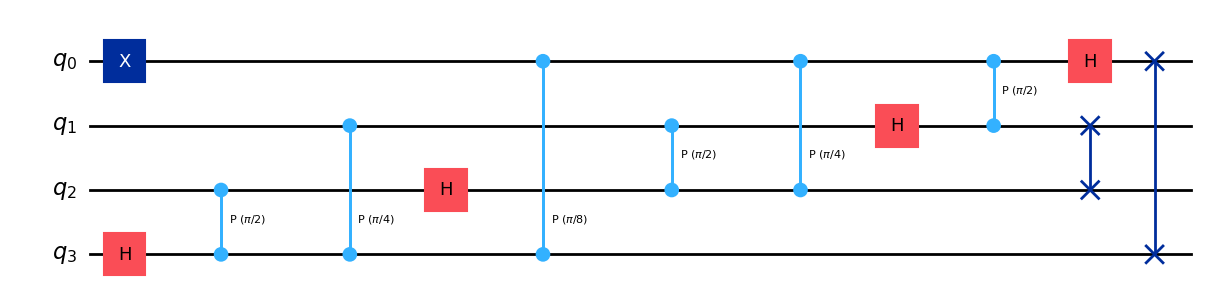

In [45]:
qc_qft = qc_input.copy()

qc_qft.compose(qft, inplace=True)

display(qc_qft.draw("mpl"))

In [46]:
from qiskit.quantum_info import Statevector

sv_qft = Statevector.from_instruction(qc_qft)

print(sv_qft)

Statevector([ 2.50000000e-01+0.j        ,  2.30969883e-01+0.09567086j,
              1.76776695e-01+0.1767767j ,  9.56708581e-02+0.23096988j,
              1.53080850e-17+0.25j      , -9.56708581e-02+0.23096988j,
             -1.76776695e-01+0.1767767j , -2.30969883e-01+0.09567086j,
             -2.50000000e-01+0.j        , -2.30969883e-01-0.09567086j,
             -1.76776695e-01-0.1767767j , -9.56708581e-02-0.23096988j,
             -1.53080850e-17-0.25j      ,  9.56708581e-02-0.23096988j,
              1.76776695e-01-0.1767767j ,  2.30969883e-01-0.09567086j],
            dims=(2, 2, 2, 2))


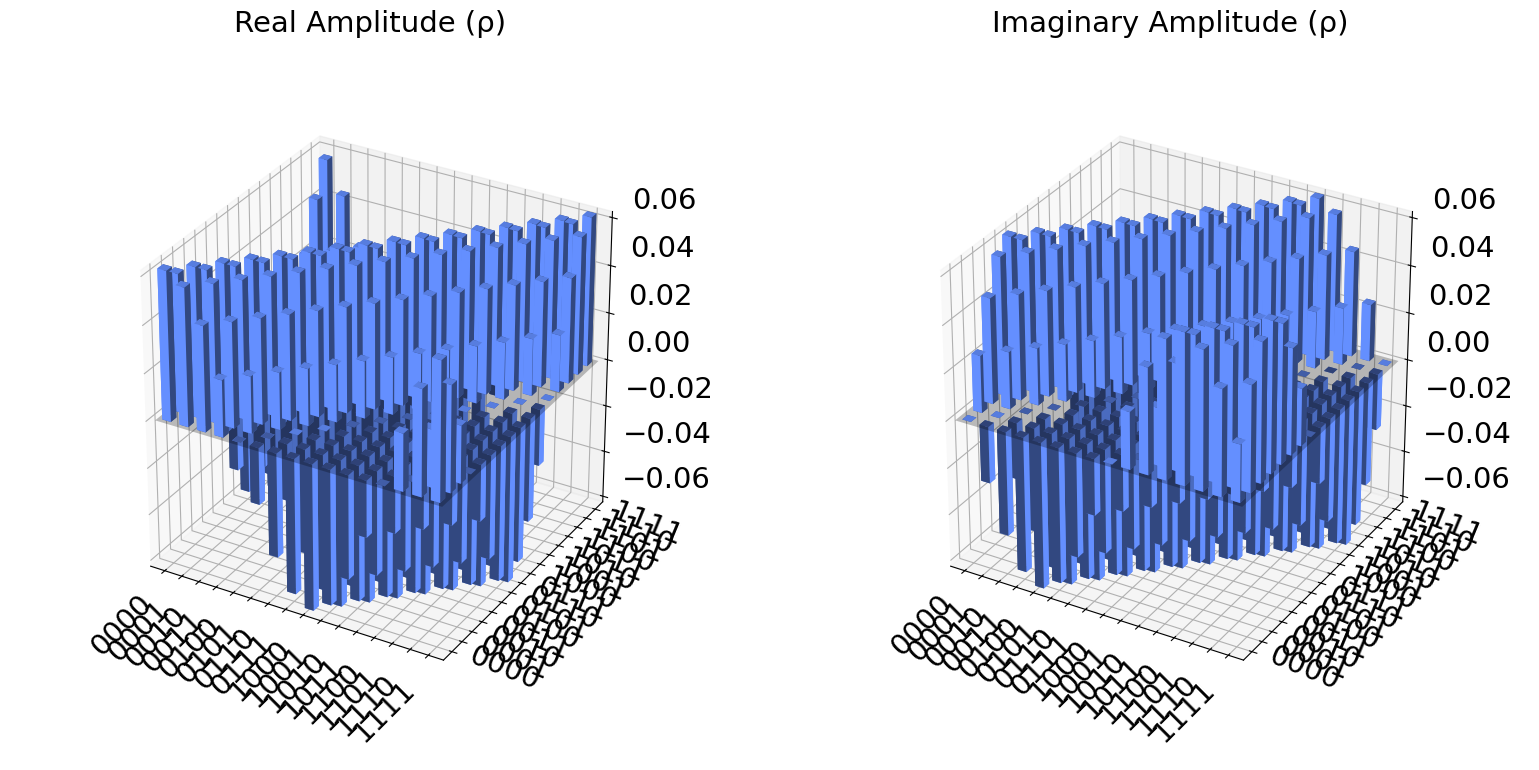

In [47]:
from qiskit.visualization import plot_state_city

plot_state_city(sv_qft)

### Observation

The QFT transforms the computational basis state into a superposition state with phase information encoded in the amplitudes.

The resulting state contains equal magnitude amplitudes with different complex phases.

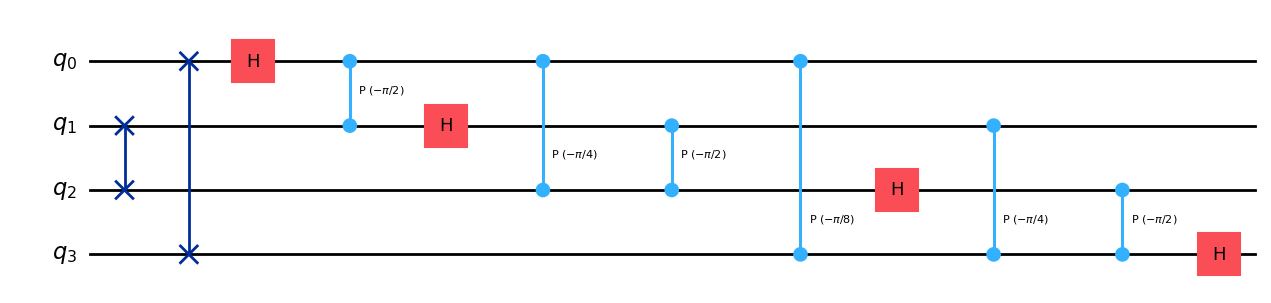

In [48]:
iqft = qft.inverse()

display(iqft.draw("mpl"))

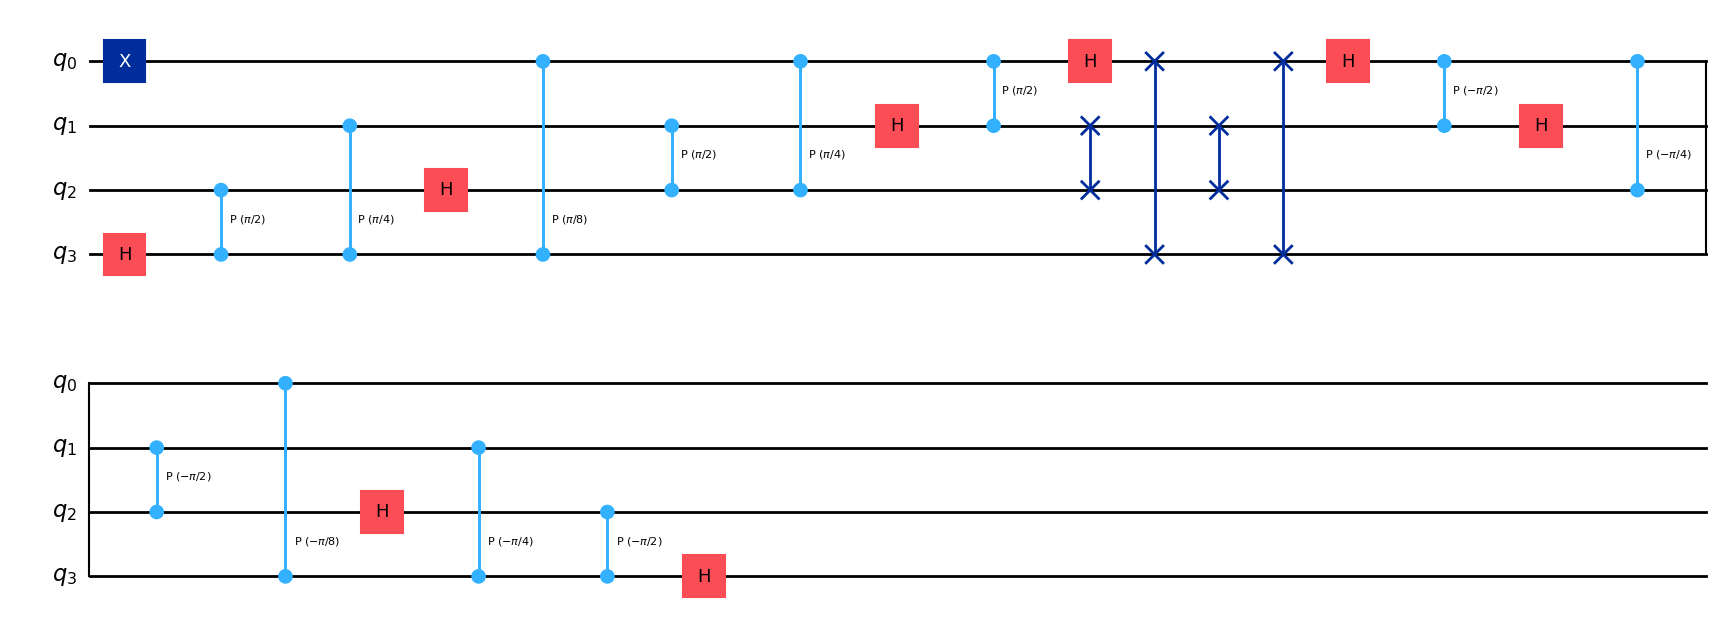

In [49]:
qc_recover = qc_qft.copy()

qc_recover.compose(iqft, inplace=True)

display(qc_recover.draw("mpl"))

In [50]:
sv_recovered = Statevector.from_instruction(qc_recover)

print(sv_recovered)

Statevector([ 1.43709198e-18-1.00835528e-18j,
              1.00000000e+00+1.96261557e-17j,
              4.06470994e-18-2.53201739e-18j,
             -7.25536224e-19-1.12083246e-18j,
              9.43959975e-19-9.57708984e-20j,
             -2.59090783e-17+2.16122220e-17j,
             -8.41828992e-19+5.42051304e-19j,
              7.22263687e-18+1.88637258e-17j,
              2.62761796e-18+7.67414354e-18j,
             -8.90187929e-18-1.96261557e-17j,
              2.38105196e-18+1.61459706e-18j,
              6.78506842e-18-2.56484791e-17j,
             -2.46566003e-19-1.80791345e-18j,
              1.24398144e-17-2.16122220e-17j,
             -8.41828992e-19-4.38673488e-18j,
              1.03336312e-17+7.90558581e-18j],
            dims=(2, 2, 2, 2))


In [52]:
from qiskit.quantum_info import state_fidelity

original = Statevector.from_instruction(qc_input)

fidelity = state_fidelity(original,sv_recovered)

print("Fidelity =", fidelity)

Fidelity = 0.9999999999999987


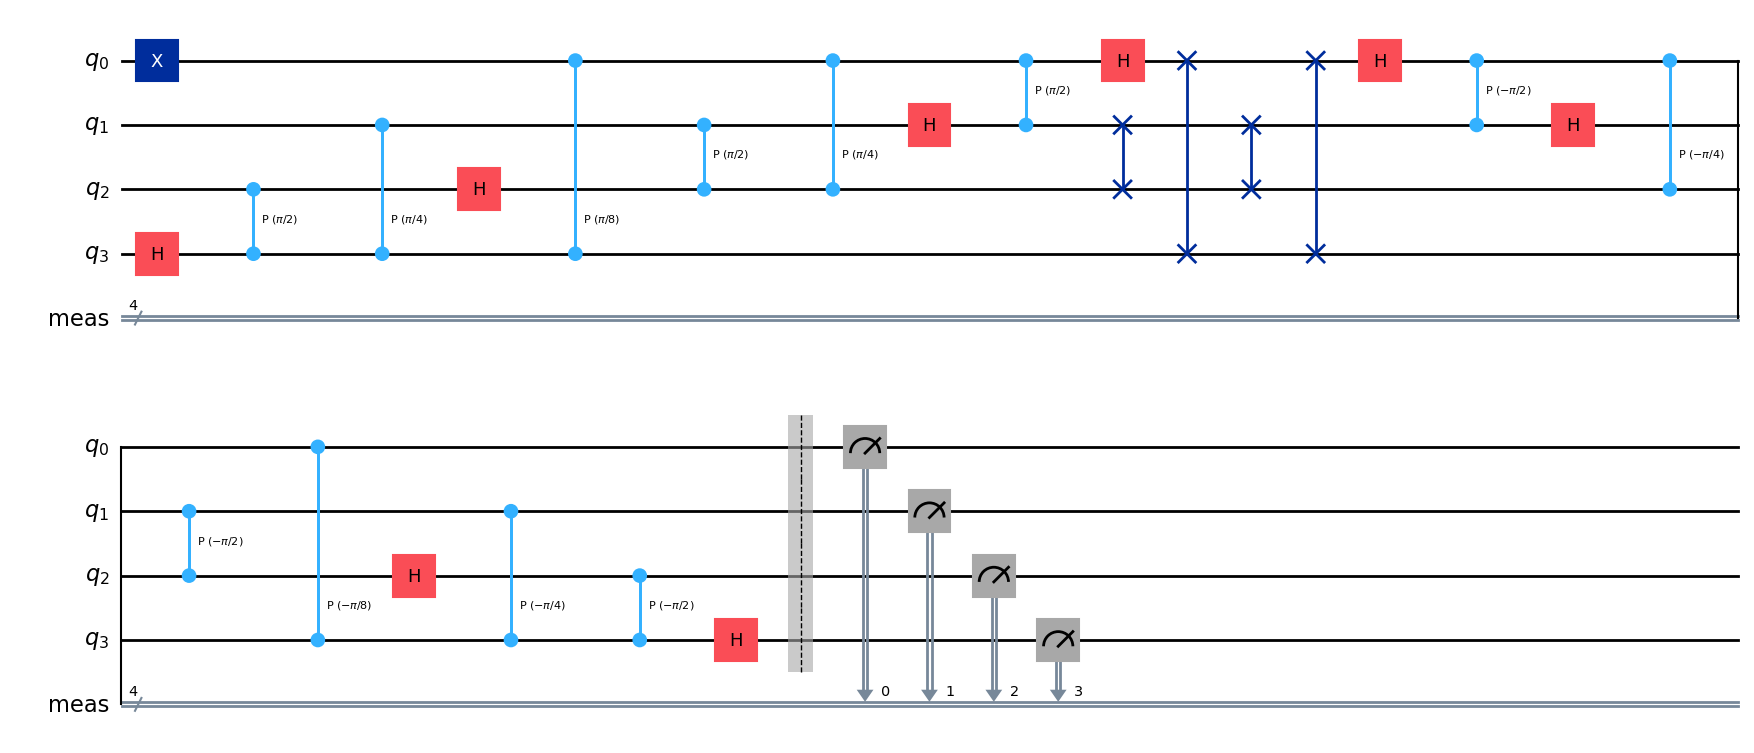

In [53]:
from qiskit import ClassicalRegister

qc_measure = qc_qft.copy()

qc_measure.compose(iqft, inplace=True)

qc_measure.measure_all()

display(qc_measure.draw("mpl"))

In [55]:
from qiskit_aer import AerSimulator
from qiskit import transpile

sim = AerSimulator()

tqc = transpile(qc_measure, sim)

result = sim.run(tqc,shots=2048).result()

counts = result.get_counts()

print(counts)

{'0001': 2048}


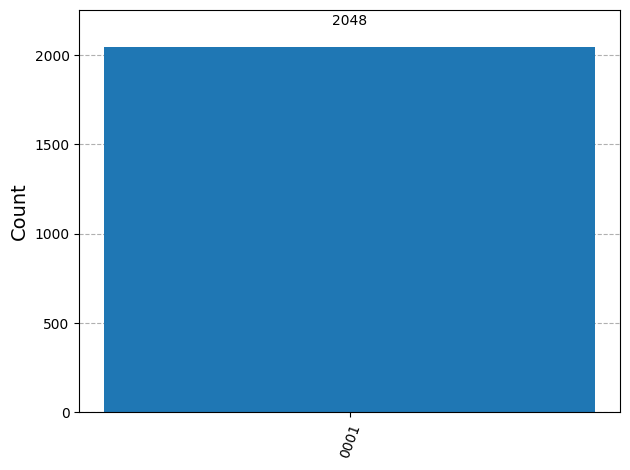

In [57]:
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

plot_histogram(counts)

### Result

The Quantum Fourier Transform was successfully applied to the state

$$
|0001\rangle
$$

and the transformed state was obtained.

The inverse QFT was then applied to recover the original state.

### Observation

The recovered state matches the original input state.

The fidelity between the initial and recovered states is approximately 1, confirming the correctness of the QFT and IQFT implementations.

The measurement results are dominated by the state

$$
|0001\rangle
$$

which verifies successful recovery of the original computational basis state.

---
---

# Task 4

## 4. Quantum Phase Estimation (QPE)

- Implement the Quantum Phase Estimation algorithm.
- Estimate the phase associated with a unitary operator.
- Verify the estimated phase using simulation results.

### Theory

Quantum Phase Estimation (QPE) is used to estimate the eigenphase of a unitary operator.

If

$$
U|\psi\rangle = e^{2\pi i \phi}|\psi\rangle
$$

where

$$
0 \le \phi < 1
$$

then QPE estimates the value of

$$
\phi
$$

using a set of counting qubits.

The algorithm consists of:

1. Initializing counting qubits in superposition.
2. Applying controlled powers of the unitary operator.
3. Applying the inverse Quantum Fourier Transform.
4. Measuring the counting register.

In [58]:
from qiskit import QuantumCircuit
from qiskit.synthesis.qft import synth_qft_full
from qiskit_aer import AerSimulator
from qiskit import transpile

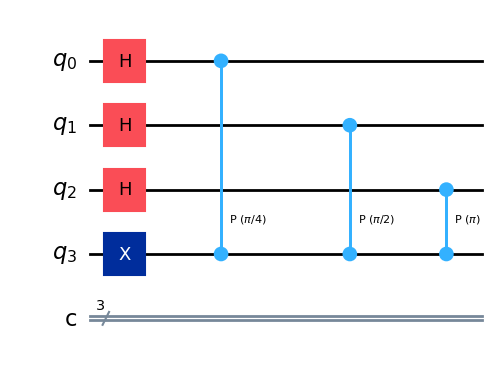

In [59]:
n_count = 3

qpe = QuantumCircuit(n_count + 1, n_count)

# Counting register
for q in range(n_count):
    qpe.h(q)

# Eigenstate |1>
qpe.x(n_count)

# Controlled-U^(2^k)

qpe.cp(np.pi/4, 0, n_count)

qpe.cp(np.pi/2, 1, n_count)

qpe.cp(np.pi, 2, n_count)

display(qpe.draw("mpl"))

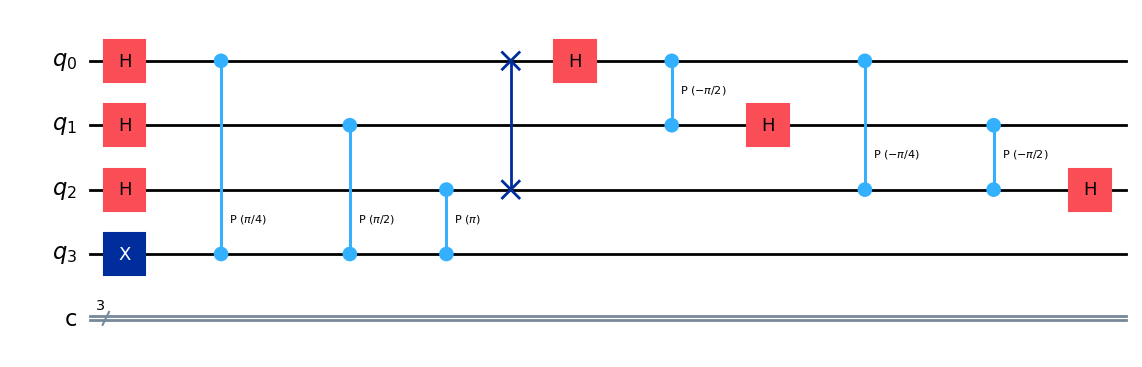

In [60]:
iqft = synth_qft_full(num_qubits=n_count,do_swaps=True).inverse()

qpe.compose(iqft, qubits=range(n_count), inplace=True)

display(qpe.draw("mpl"))

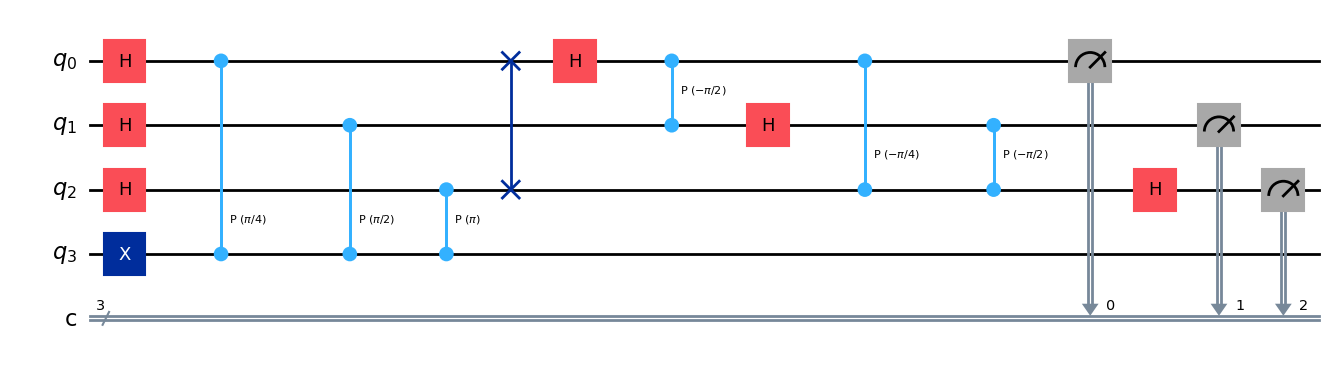

In [61]:
qpe.measure(range(n_count), range(n_count))

display(qpe.draw("mpl"))

In [62]:
sim = AerSimulator()

tqc = transpile(qpe, sim)

result = sim.run(
    tqc,
    shots=2048
).result()

counts = result.get_counts()

print(counts)

{'001': 2048}


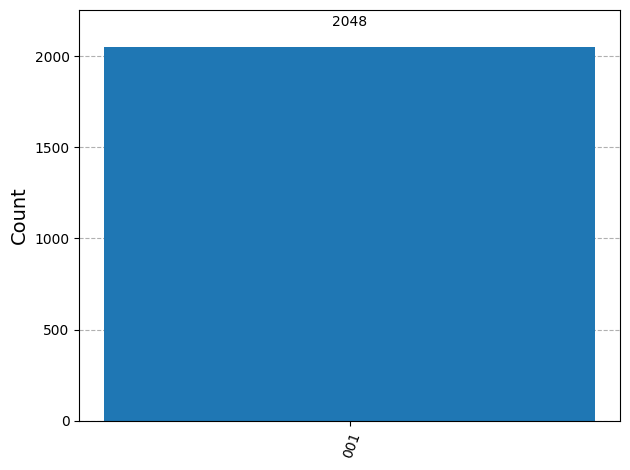

In [64]:
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

plot_histogram(counts)

In [65]:
measured_state = max(counts, key=counts.get)

phase_estimate = int(measured_state, 2) / (2**n_count)

print("Measured State :", measured_state)
print("Estimated Phase :", phase_estimate)

Measured State : 001
Estimated Phase : 0.125


### Result

The Quantum Phase Estimation algorithm was implemented using three counting qubits and one eigenstate qubit.

The phase associated with the unitary operator

$$
U = P(\pi/4)
$$

was successfully estimated.

### Observation

The measurement outcome was dominated by the binary state

$$
001
$$

which corresponds to

$$
0.001_2 = \frac{1}{8}
$$

The estimated phase matched the theoretical phase value

$$
\phi = \frac{1}{8}
$$

demonstrating the correctness of the Quantum Phase Estimation algorithm.

---
---